### ADVICE CONDITION

In [2]:
import pandas as pd
import os

df_adv = pd.read_csv(os.path.join(os.path.dirname(os.getcwd()), "NLP", "results", "docs_topic_weights_reduce_outlier.csv"))
df_adv.head()

,ID,understanding_score,pl1_understanding,pl2_understanding,score_corrected,rank,filename,binary_score,ADVICE,gen,...,assigned_topic,parent_topic_0,parent_topic_1,parent_topic_2,parent_topic_3,parent_topic_4,parent_topic_5,parent_topic_6,parent_topic_7,parent_topic_8
0,557c0bd8fdf99b120dc45dde,0.450602,0.823568,0.077637,0.036000,61,231648_experiment_2024-05-15_18h56.19.209.csv,0.550781,Consider each round carefully as it appears th...,1,...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,55cca8f81676ab000ff06ef1,0.046999,0.068651,0.025347,-0.831984,98,977227_experiment_2024-05-15_18h41.00.488.csv,0.562500,"If the multiplier is 5, then choose the pointy...",1,...,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,561f684fed6e5a000dc7e878,-0.011316,-0.072371,0.049740,0.065737,57,517641_experiment_2024-05-15_18h58.56.170.csv,0.550781,The game is fantastic but requires you to thin...,1,...,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,56e9c7ac0a5579000d8f7dd4,0.493623,0.967023,0.020224,0.104839,55,187094_experiment_2024-05-15_18h45.57.869.csv,0.546875,My advice would be to pay attention to the col...,1,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,57681fca8e454c000133a203,0.497338,0.941127,0.053548,0.462151,31,621764_experiment_2024-05-15_19h49.20.832.csv,0.566406,"Do not let the timer worry you, but make sure ...",1,...,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
from yfiles_jupyter_graphs import GraphWidget

nodes = []
edges = []

for row in df_adv.iterrows():
    ID = row[1]["ID"]
    pID = row[1]["parent_ID"]
    gen = row[1]["gen"]
    topic = row[1]["assigned_topic"]
    rank = row[1]["rank"]
    advice = row[1]["ADVICE"]
    nodes.append(
        {"id": ID, "properties": {"gen": gen, "topic": topic, "label": rank, "advice": advice}}
    )
    edges.append(
        {"start": pID, "end": ID}
    )
    

node_colors = {}


def custom_style_mapping(index, node):
    color_palette = [
        "#0072B2",  # Blue
        "#E69F00",  # Orange
        "#009E73",  # Green
        "#D55E00",  # Red
        "#CC79A7",  # Purple
        "#A65628",  # Brown
        "#F0E442",  # Yellow
        "#D6C700",  # Yellow-Green
        "#00CFE3"   # Cyan
    ]
    shape_palette = [
        "rectangle",
        "round-rectangle",
        "ellipse",
        "triangle",
        "hexagon",
        "octagon",
        "parallelogram",
        "trapezoid",
        "diamond"
    ]

    topic = node.get("properties", {}).get("topic", 0)  # Default to 0 if missing
    label = node.get("properties", {}).get("label", "")

    

    if topic == -1:
        color = "grey"
        shape = "triangle"  # Note: 'triangle_pointing_right' might not be supported; use 'triangle' or 'right-triangle'
    
    elif topic in [2, 4, 8]:
        color = color_palette[1]
        shape = shape_palette[1]
    elif topic in [0, 1]:
        color = color_palette[0]
        shape = shape_palette[0]
    else:
        color = color_palette[topic % len(color_palette)]  # Protect against overflow
        shape = shape_palette[topic % len(shape_palette)]  # Protect against overflow

    node_colors[node["id"]] = color

    # Return proper style dict
    return {
        "shape": shape,
        "color": color,
        "stroke": "black",  # Optional: for border color
        "label": label,
        "text": advice
    }

def custom_edge_color_mapping(index, edge):
    source_id = edge["start"]  # The starting node ID of this edge
    color = node_colors.get(source_id, "black")  # Default to black if not found
    return color



w = GraphWidget()
w.nodes = nodes
w.edges = edges
w.set_node_styles_mapping(custom_style_mapping)
w.set_edge_color_mapping(custom_edge_color_mapping)
w.directed = True
w.organic_layout()

display(w)

GraphWidget(layout=Layout(height='800px', width='100%'))

### OBSERVATION CONDITION

In [4]:
import pandas as pd
import os

df_obs = pd.read_csv(os.path.join(os.path.dirname(os.getcwd()), "output", "processed", "data_obs.csv"))
df_obs.head()

,Unnamed: 0,ID,understanding_score,pl1_understanding,pl2_understanding,score_corrected,rank,filename,binary_score,gen,...,parent_understanding_score,parent_pl1_understanding,parent_pl2_understanding,parent_score_corrected,parent_rank,parent_filename,parent_ADVICE,parent_gen,parent_binary_score,parent_n_miss
0,1,575865ba7b74a80006de2689,0.350785,0.902381,-0.200810,0.843750,15,908848_experiment_2024-10-01_09h22.48.378.csv,0.574219,1,...,0.0,0.0,0.0,0.0,0,NaN,NaN,0,NaN,NaN
1,2,575b2b408b705300078ae5e6,0.245500,0.452088,0.038911,-0.047619,71,961729_experiment_2024-10-01_17h19.23.734.csv,0.550781,1,...,0.0,0.0,0.0,0.0,0,NaN,NaN,0,NaN,NaN
2,3,57b76ef5017c2d000166f019,0.109449,0.235450,-0.016551,0.529528,30,223814_experiment_2024-10-01_17h28.15.857.csv,0.605469,1,...,0.0,0.0,0.0,0.0,0,NaN,NaN,0,NaN,NaN
3,4,57ff8c2d90de420001673aa0,0.084324,0.136036,0.032611,0.245098,53,687549_experiment_2024-10-01_17h24.29.298.csv,0.535156,1,...,0.0,0.0,0.0,0.0,0,NaN,NaN,0,NaN,NaN
4,5,5848ad3bdb871400012da095,0.269850,0.474537,0.065162,-0.614583,96,247730_experiment_2024-10-01_10h28.44.942.csv,0.535156,1,...,0.0,0.0,0.0,0.0,0,NaN,NaN,0,NaN,NaN


In [ ]:
from yfiles_jupyter_graphs import GraphWidget

nodes = []
edges = []

for row in df_obs.iterrows():
    ID = row[1]["ID"]
    pID = row[1]["parent_ID"]
    gen = row[1]["gen"]
    rank = row[1]["rank"]
    nodes.append(
        {"id": ID, "properties": {"gen": gen, "label": rank}}
    )
    edges.append(
        {"start": pID, "end": ID}
    )
    

w = GraphWidget()
w.nodes = nodes
w.edges = edges
w.directed = True
w.organic_layout()

display(w)

GraphWidget(layout=Layout(height='800px', width='100%'))

In [ ]:
n_grandchild = []
ids = []
for row in df_obs.iterrows():
    id_grandparent = row[1]["ID"]
    df_child = df_obs[df_obs["parent_ID"] == id_grandparent]
    ids.append(id_grandparent)
    for row_child in df_child.iterrows():
        id_parent = row_child[1]["ID"]
        df_grandchild = df_obs[df_obs["parent_ID"] == id_parent]
        n_grandchild.append(len(df_grandchild))

sum(n_grandchild) / len(n_grandchild)

0.8863636363636364

In [ ]:
n_grandchild = []
ids = []
for row in df_adv.iterrows():
    id_grandparent = row[1]["ID"]
    df_child = df_adv[df_adv["parent_ID"] == id_grandparent]
    ids.append(id_grandparent)
    for row_child in df_child.iterrows():
        id_parent = row_child[1]["ID"]
        df_grandchild = df_adv[df_adv["parent_ID"] == id_parent]
        n_grandchild.append(len(df_grandchild))

sum(n_grandchild) / len(n_grandchild)

56e9c7ac0a5579000d8f7dd4 1
57681fca8e454c000133a203 4
57681fca8e454c000133a203 4
57681fca8e454c000133a203 4
57681fca8e454c000133a203 4
57a5c633275be6000135b61c 1
57b77ad86615e5000160ea97 1
5977986837d15f00016f1d08 3
5977986837d15f00016f1d08 3
5977986837d15f00016f1d08 3
59f392ef9618dc0001d33a58 1
5b126b7ebd9c31000156c3b9 1
5b460b3678d6310001b74803 3
5b460b3678d6310001b74803 3
5b460b3678d6310001b74803 3
5b52f4933234ab00014ca442 5
5b52f4933234ab00014ca442 5
5b52f4933234ab00014ca442 5
5b52f4933234ab00014ca442 5
5b52f4933234ab00014ca442 5
5ca73fe6bcdcc2001291822d 1
5d1a1d97a51463000183f7af 4
5d1a1d97a51463000183f7af 4
5d1a1d97a51463000183f7af 4
5d1a1d97a51463000183f7af 4
5d66f49c531d6e0001e99e8a 2
5d66f49c531d6e0001e99e8a 2
5d9ca4eff93dba0013e68c11 4
5d9ca4eff93dba0013e68c11 4
5d9ca4eff93dba0013e68c11 4
5d9ca4eff93dba0013e68c11 4
5da83385e8bf0200113c3c6e 3
5da83385e8bf0200113c3c6e 3
5da83385e8bf0200113c3c6e 3
5ddac93016d10ca2991f7dbf 1
5e84c792bde837092ec273de 1
5e933bbce6812e6768a81eb9 2
5

0.8888888888888888

900

## TREE METRICS


=== Summary of Lineage Metrics by Condition ===
           lineage_depth  lineage_size  branching_factor
condition                                               
ADV                 1.50           9.0          0.359626
OBS                 1.74           8.8          0.336092

=== Statistical Comparisons Between Conditions ===
                  mean_OBS  mean_ADV  t_test_p  u_test_p
lineage_depth     1.740000  1.500000  0.513117  0.931423
lineage_size      8.800000  9.000000  0.966651  0.790345
branching_factor  0.336092  0.359626  0.684075  0.790345

=== Plotting Survival Curves ===


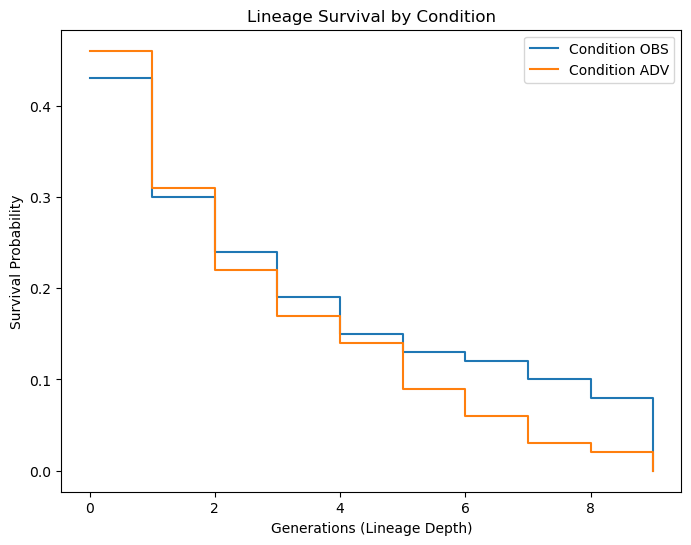

,root_ID,condition,lineage_depth,lineage_size,branching_factor
0,575865ba7b74a80006de2689,OBS,8,28,0.965517
1,575b2b408b705300078ae5e6,OBS,1,2,0.666667
2,57b76ef5017c2d000166f019,OBS,5,13,0.928571
3,57ff8c2d90de420001673aa0,OBS,1,1,0.500000
4,5848ad3bdb871400012da095,OBS,0,0,0.000000
...,...,...,...,...,...
195,663827f44936c1ad8d008b68,ADV,0,0,0.000000
196,663b7ad234b11a3aa63c6685,ADV,0,0,0.000000
197,6640edf60de1f01b4cc686dd,ADV,0,0,0.000000
198,6643dcdaee723e90ec897171,ADV,3,10,0.909091


In [105]:
import pandas as pd
import networkx as nx
import os
from lifelines import KaplanMeierFitter
from scipy.stats import ttest_ind, mannwhitneyu
import matplotlib.pyplot as plt

# ---------------------------
# Load your dataset
# ---------------------------

df_obs = pd.read_csv(os.path.join(os.path.dirname(os.getcwd()), "output", "processed", "data_obs.csv"))
df_adv = pd.read_csv(os.path.join(os.path.dirname(os.getcwd()), "NLP", "results", "docs_topic_weights_reduce_outlier.csv"))

df_obs["condition"] = "OBS"
df_adv["condition"] = "ADV"

data = pd.concat([df_obs, df_adv])

# ---------------------------
# Build Lineage Graph
# ---------------------------

def build_graph(data):
    G = nx.DiGraph()
    for _, row in data.iterrows():
        G.add_node(row['ID'], generation=row['gen'], score=row['score_corrected'], condition=row['condition'])
        if pd.notna(row['parent_ID']):
            G.add_edge(row['parent_ID'], row['ID'])
    return G

# ---------------------------
# Compute Lineage Metrics
# ---------------------------

def lineage_depth(G, root):
    lengths = nx.single_source_shortest_path_length(G, root)
    return max(lengths.values())

def lineage_size(G, root):
    return len(nx.descendants(G, root))

def branching_factor(G, root):
    lineage_nodes = nx.descendants(G, root) | {root}
    return sum(len(list(G.successors(n))) for n in lineage_nodes) / len(lineage_nodes)

# ---------------------------
# Aggregate Lineage Metrics
# ---------------------------

def analyze_lineages(data, G):
    roots = data.loc[data['parent_ID'].str.startswith('fake '), 'ID'].tolist()
    root_conditions = data.set_index('ID')['condition'].to_dict()
    
    results = []
    for root in roots:
        results.append({
            'root_ID': root,
            'condition': root_conditions[root],
            'lineage_depth': lineage_depth(G, root),
            'lineage_size': lineage_size(G, root),
            'branching_factor': branching_factor(G, root)
        })
    
    return pd.DataFrame(results)

# ---------------------------
# Survival Analysis (Kaplan-Meier)
# ---------------------------

def plot_survival(results):
    kmf = KaplanMeierFitter()

    plt.figure(figsize=(8, 6))
    for condition in results['condition'].unique():
        lifetimes = results.loc[results['condition'] == condition, 'lineage_depth']
        kmf.fit(lifetimes, event_observed=[1] * len(lifetimes), label=f"Condition {condition}")
        kmf.plot_survival_function(ci_show=False)

    plt.title("Lineage Survival by Condition")
    plt.xlabel("Generations (Lineage Depth)")
    plt.ylabel("Survival Probability")
    plt.legend()
    plt.show()

# ---------------------------
# Statistical Tests
# ---------------------------

def compare_conditions(results):
    metrics = ['lineage_depth', 'lineage_size', 'branching_factor']
    conditions = results['condition'].unique()
    if len(conditions) != 2:
        raise ValueError("Currently set up for exactly two conditions.")
    
    cond1, cond2 = conditions
    summary = {}
    for metric in metrics:
        x = results.loc[results['condition'] == cond1, metric]
        y = results.loc[results['condition'] == cond2, metric]
        
        t_stat, t_pval = ttest_ind(x, y, equal_var=False)
        u_stat, u_pval = mannwhitneyu(x, y, alternative='two-sided')
        
        summary[metric] = {
            'mean_{}'.format(cond1): x.mean(),
            'mean_{}'.format(cond2): y.mean(),
            't_test_p': t_pval,
            'u_test_p': u_pval
        }
    return pd.DataFrame(summary).T

# ---------------------------
# Master Function to Run All
# ---------------------------

def run_lineage_analysis(data):
    G = build_graph(data)
    results = analyze_lineages(data, G)
    print("\n=== Summary of Lineage Metrics by Condition ===")
    print(results.groupby('condition')[['lineage_depth', 'lineage_size', 'branching_factor']].mean())
    
    print("\n=== Statistical Comparisons Between Conditions ===")
    stats = compare_conditions(results)
    print(stats)
    
    print("\n=== Plotting Survival Curves ===")
    plot_survival(results)
    
    return results, stats

# ---------------------------
# Example Usage
# ---------------------------

results, stats = run_lineage_analysis(data)

# You can export the results if needed
# results.to_csv("lineage_metrics.csv", index=False)
# stats.to_csv("lineage_stats.csv", index=True)

results

In [ ]:
results["lineage_depth"]
print(results[results["condition"] == "OBS"]["lineage_size"].max())
print(results[results["condition"] == "ADV"]["lineage_size"].max())

NameError: name 'results' is not defined

## SIMULATION

In [146]:
import pandas as pd
import numpy as np

def create_population(n, gen, parent_info=None):
    """Create a population of agents with random scores and ranks."""
    scores = np.random.normal(0, 1, size=n)
    ids = [f"h_{gen}-{i}" for i in range(n)]
    pop = pd.DataFrame({
        "id": ids,
        "score": scores,
        "gen": gen,
        "rank": pd.Series(scores).rank(method='first', ascending=False)  # Rank the scores
    })

    if parent_info:
        pop["parent_id"], pop["parent_score"], pop["parent_rank"] = parent_info
    return pop

def tournament_selection(pop, k=4):
    """Select a parent using tournament selection from the population."""
    selected_pop = pop.sample(n=k)
    best_parent = pop.loc[selected_pop["score"].idxmax()]
    return best_parent

def transmission_score(parent_scores, transmission_quality):
    """Generate scores based on parent scores and transmission quality."""
    mu = parent_scores * transmission_quality
    return np.random.normal(mu, 1)


def run_simulation(n, n_gen, transmission_quality):
    """Simulate the evolutionary process over multiple generations."""
    # Initial population
    pop = create_population(n, gen=0)

    # Initialize dataframe to store results
    data = pop[["id", "score", "gen", "rank"]].copy()
    data["parent_id"], data["parent_score"], data["parent_rank"] = np.nan, np.nan, np.nan

    # Simulate each generation
    for gen in range(1, n_gen + 1):
        parent_info = [], [], []  # For storing parent data across all agents
        for agent in range(n):
            parent = tournament_selection(pop, k=4)
            parent_info[0].append(parent["id"])  # parent_id
            parent_info[1].append(parent["score"])  # parent_score
            parent_info[2].append(parent["rank"])  # parent_rank

        # Generate new scores for the next generation
        gen_scores = transmission_score(np.array(parent_info[1]), transmission_quality)

        # Create the new generation's DataFrame
        gen_data = create_population(n, gen, parent_info)
        gen_data["score"] = gen_scores
        gen_data["rank"] = gen_data["score"].rank(method='first', ascending=False)

        # Append to the data for all generations
        data = pd.concat([data, gen_data])

        # Set the population for the next generation
        pop = gen_data

    return data


# Parameters
n = 100  # population size
n_gen = 10  # number of generations
transmission_quality = [0, 0.2, 0.4, 0.6, 0.8, 1]  # transmission quality
n_sim = len(transmission_quality)
# Run the simulation
data_list = []
for i in range(n_sim):
    data_sim = run_simulation(n, n_gen, transmission_quality=transmission_quality[i])
    data_sim["sim"] = i
    data_sim["transmission_quality"] = transmission_quality[i]
    data_list.append(data_sim)

data = pd.concat(data_list, ignore_index=True)

In [152]:
from yfiles_jupyter_graphs import GraphWidget

nodes = []
edges = []

df_graph = data.query("sim == 4")

for row in df_graph.iterrows():
    ID = row[1]["id"]
    pID = row[1]["parent_id"]
    gen = row[1]["gen"]
    rank = row[1]["rank"]
    nodes.append(
        {"id": ID, "properties": {"gen": gen, "label": rank}}
    )
    edges.append(
        {"start": pID, "end": ID}
    )

w = GraphWidget()
w.nodes = nodes
w.edges = edges
w.directed = True
w.organic_layout()

display(w)

GraphWidget(layout=Layout(height='800px', width='100%'))

In [ ]:
import pandas as pd
import networkx as nx
import os
from lifelines import KaplanMeierFitter
from scipy.stats import ttest_ind, mannwhitneyu
import matplotlib.pyplot as plt

# ---------------------------
# Build Lineage Graph
# ---------------------------

def build_graph(data):
    G = nx.DiGraph()
    for _, row in data.iterrows():
        G.add_node(row['id'], generation=row['gen'], score=row['score'], condition=row['transmission_quality'])
        if pd.notna(row['parent_id']):
            G.add_edge(row['parent_id'], row['id'])
    return G




In [ ]:

# ---------------------------
# Compute Lineage Metrics
# ---------------------------

def lineage_depth(G, root):
    lengths = nx.single_source_shortest_path_length(G, root)
    return max(lengths.values())

def lineage_size(G, root):
    return len(nx.descendants(G, root))

def branching_factor(G, root):
    lineage_nodes = nx.descendants(G, root) | {root}
    return sum(len(list(G.successors(n))) for n in lineage_nodes) / len(lineage_nodes)

# ---------------------------
# Aggregate Lineage Metrics
# ---------------------------

def analyze_lineages(data, G):
    roots = data.loc[data['parent_ID'].str.startswith('fake '), 'ID'].tolist()
    root_conditions = data.set_index('id')['transmission_quality'].to_dict()
    
    results = []
    for root in roots:
        results.append({
            'root_ID': root,
            'condition': root_conditions[root],
            'lineage_depth': lineage_depth(G, root),
            'lineage_size': lineage_size(G, root),
            'branching_factor': branching_factor(G, root)
        })
    
    return pd.DataFrame(results)

# ---------------------------
# Survival Analysis (Kaplan-Meier)
# ---------------------------

def plot_survival(results):
    kmf = KaplanMeierFitter()

    plt.figure(figsize=(8, 6))
    for condition in results['condition'].unique():
        lifetimes = results.loc[results['condition'] == condition, 'lineage_depth']
        kmf.fit(lifetimes, event_observed=[1] * len(lifetimes), label=f"Condition {condition}")
        kmf.plot_survival_function(ci_show=False)

    plt.title("Lineage Survival by Condition")
    plt.xlabel("Generations (Lineage Depth)")
    plt.ylabel("Survival Probability")
    plt.legend()
    plt.show()

# ---------------------------
# Statistical Tests
# ---------------------------

def compare_conditions(results):
    metrics = ['lineage_depth', 'lineage_size', 'branching_factor']
    conditions = results['condition'].unique()
    if len(conditions) != 2:
        raise ValueError("Currently set up for exactly two conditions.")
    
    cond1, cond2 = conditions
    summary = {}
    for metric in metrics:
        x = results.loc[results['condition'] == cond1, metric]
        y = results.loc[results['condition'] == cond2, metric]
        
        t_stat, t_pval = ttest_ind(x, y, equal_var=False)
        u_stat, u_pval = mannwhitneyu(x, y, alternative='two-sided')
        
        summary[metric] = {
            'mean_{}'.format(cond1): x.mean(),
            'mean_{}'.format(cond2): y.mean(),
            't_test_p': t_pval,
            'u_test_p': u_pval
        }
    return pd.DataFrame(summary).T

# ---------------------------
# Master Function to Run All
# ---------------------------

def run_lineage_analysis(data):
    G = build_graph(data)
    results = analyze_lineages(data, G)
    print("\n=== Summary of Lineage Metrics by Condition ===")
    print(results.groupby('condition')[['lineage_depth', 'lineage_size', 'branching_factor']].mean())
    
    print("\n=== Statistical Comparisons Between Conditions ===")
    stats = compare_conditions(results)
    print(stats)
    
    print("\n=== Plotting Survival Curves ===")
    plot_survival(results)
    
    return results, stats

# ---------------------------
# Example Usage
# ---------------------------

results, stats = run_lineage_analysis(data)

# You can export the results if needed
# results.to_csv("lineage_metrics.csv", index=False)
# stats.to_csv("lineage_stats.csv", index=True)

results

In [133]:

nodes = []
edges = []

df_graph = data.query("sim" == 1)

for row in df_graph.iterrows():
    ID = row[1]["id"]
    pID = row[1]["parent_id"]
    gen = row[1]["gen"]
    rank = row[1]["rank"]
    nodes.append(
        {"id": ID, "properties": {"gen": gen, "label": rank}}
    )
    edges.append(
        {"start": pID, "end": ID}
    )
    

w = GraphWidget()
w.nodes = nodes
w.edges = edges
w.directed = True
w.organic_layout()

display(w)

ValueError: expr must be a string to be evaluated, <class 'bool'> given

<function matplotlib.pyplot.show(close=None, block=None)>

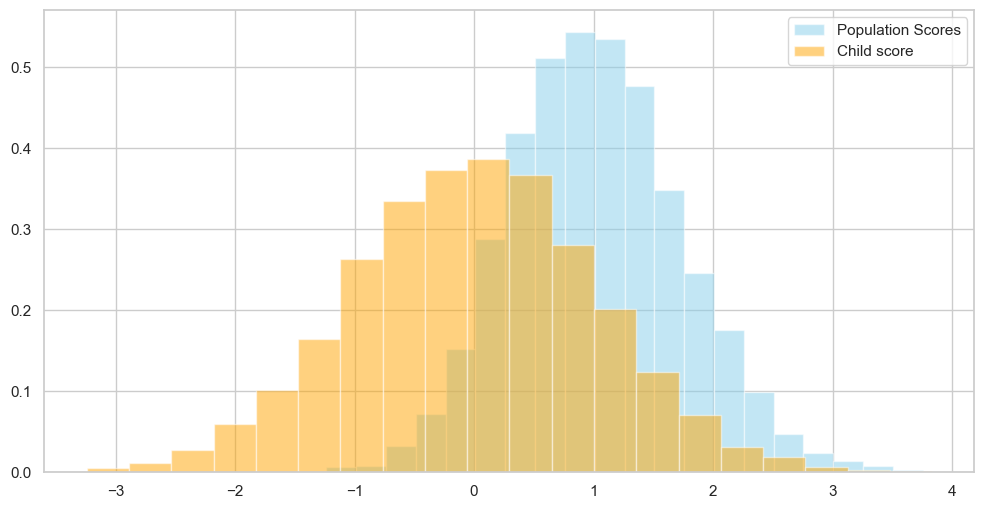

In [ ]:




# plt.figure(figsize=(12, 6))
# plt.hist(parent_scores, color='skyblue', label='Population Scores', bins=20, density=True, alpha = 0.5)
# plt.hist(a, color='orange', label='Child score', bins=20, density=True, alpha = 0.5)
# plt.legend()
# plt.show


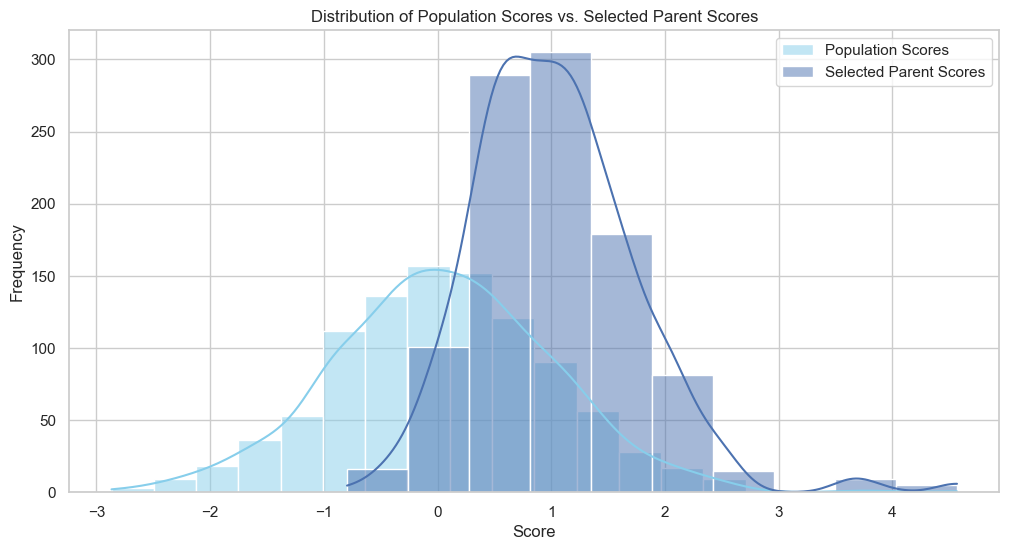

<function matplotlib.pyplot.show(close=None, block=None)>

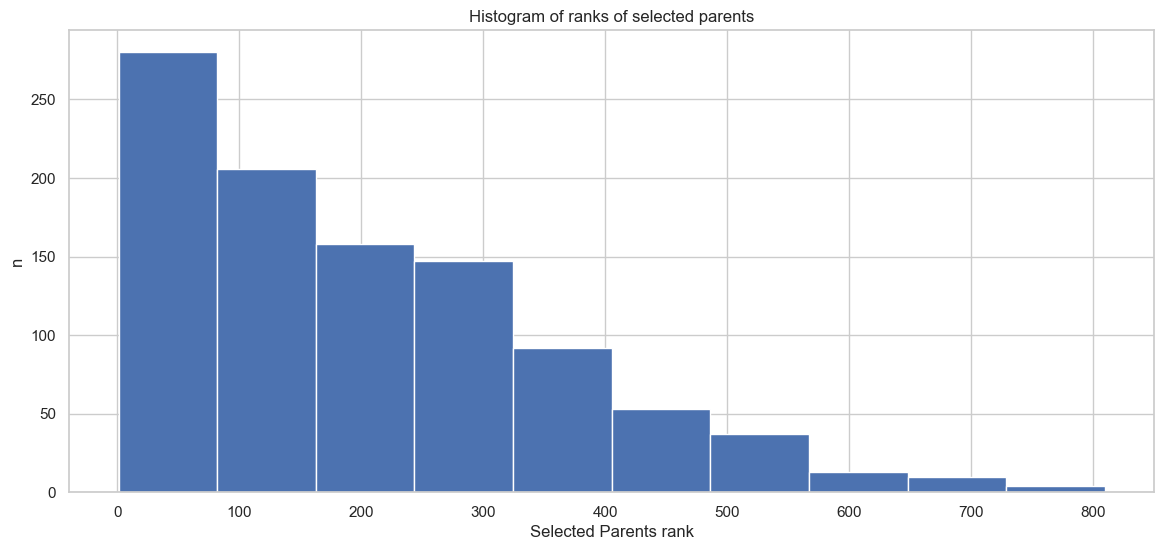

In [86]:

# --------- Plotting ---------

# Set style
sns.set(style="whitegrid")

# Plot population score distribution
plt.figure(figsize=(12, 6))
sns.histplot(pop["score"], kde=True, color='skyblue', label='Population Scores', bins=20)
sns.histplot(parent_scores, kde=True, color='orange', label='Selected Parent Scores', bins=10)
plt.legend()
plt.title("Distribution of Population Scores vs. Selected Parent Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()


plt.figure(figsize=(14, 6))
plt.hist(parent_ranks)
plt.xlabel("Selected Parents rank")
plt.ylabel("n")
plt.title("Histogram of ranks of selected parents")
plt.show